In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pillow_lab_rotation import lds
from pillow_lab_rotation.simulate import LDSSim
from importlib import reload
inv = np.linalg.inv
plt.style.use('../JS.mplstyle')

In [2]:
def generate_outreach_data(n_trials: int, T: int, noise: float=0.05):
    thetas = np.deg2rad(np.linspace(0, 360, 9))[:-1]
    r = np.linspace(0, 1, T)
    X = np.zeros((n_trials, T, 2, 1))
    
    for n in range(n_trials):
        theta = np.random.choice(thetas)
        x = r * np.cos(theta) + np.random.normal(0, noise, T)
        y = r * np.sin(theta) + np.random.normal(0, noise, T)
        X[n] = np.array([x, y]).T[..., None]
    
    return X

# Test to see if arbitrary invertible $H$ changes log-likelihood

It shouldn't!

In [3]:
X = generate_outreach_data(50000, 25)

In [4]:
xdim = 2
ydim = 2

model = lds.LinearDynamicalSystem(xdim=2, ydim=2)

In [5]:
model.fit(X)

In [6]:
model.predict(X)[-1] / (50000 * 25) - model.LL

np.float64(0.0)

# Change parameters

In [7]:
H = np.random.standard_normal((ydim, ydim))
H_inv = np.linalg.inv(H)

model.A = H @ model.A @ H_inv
model.C = model.C @ H_inv
model.Q = H @ model.Q @ H.T
model.Q0 = H @ model.Q0 @ H.T

# Look at log-likelihood again

In [8]:
transformed_ll = model.predict(X)[-1] / (50000 * 25)
print(f'Transformed model LL: {transformed_ll}')
print(f'Original model LL: {model.LL}')
print(f'Delta: {transformed_ll - model.LL}')

Transformed model LL: 2.6338493123201614
Original model LL: 2.6338898858198525
Delta: -4.0573499691110015e-05


### Now let's see if the MSE between the fitted parameters and the ground-truth parameters also goes down monotonically with the amount of data. The CTDS model inherits most of its functionalitry from the LDS model, so this should diagnose if it is something to do with the 

In [9]:
from pillow_lab_rotation.plotting import plot_ctds_matrices

In [16]:
reload(lds)

<module 'pillow_lab_rotation.lds' from '/Users/jeremyschroeter/Desktop/the-ark/phd/rotations/pillow_lab_rotation/src/pillow_lab_rotation/lds.py'>

In [21]:
xdim, ydim = 5, 10
simulation = LDSSim(xdim, ydim)
np.random.seed(42)
simulation.create_params()
trial_list = [50, 100, 200, 500, 1000, 1500, 2000, 5000, 10000, 20000, 40000]
X_all, Y_all = simulation.simulate(100, trial_list[-1])

A_loss = []
C_loss = []
Q_loss = []
R_loss = []

A_true, C_true, Q_true, Q0_true, _, R_true = simulation.get_params()

for n_trials in trial_list:
    print(f'Fitting with {n_trials} trials')
    Y = Y_all[:n_trials]
    np.random.seed(0)
    lds_model = lds.LinearDynamicalSystem(xdim, ydim)
    lds_model.fit(Y, max_iter=100)

    C_prime = lds_model.C
    H = np.linalg.inv(C_prime.T @ C_prime) @ C_prime.T @ C_true
    H_inv = np.linalg.inv(H)

    A_rec = H_inv @ lds_model.A @ H
    C_rec = lds_model.C @ H
    Q_rec = H_inv @ lds_model.Q @ H_inv.T

    A_loss.append(np.mean((A_rec - A_true)**2))
    C_loss.append(np.mean((C_rec - C_true)**2))
    Q_loss.append(np.mean((Q_rec - Q_true)**2))
    R_loss.append(np.mean((lds_model.R - R_true)**2))

Fitting with 50 trials
Fitting with 100 trials
Fitting with 200 trials
Fitting with 500 trials
Fitting with 1000 trials
Fitting with 1500 trials
Fitting with 2000 trials
Fitting with 5000 trials
Fitting with 10000 trials
Fitting with 20000 trials
Fitting with 40000 trials


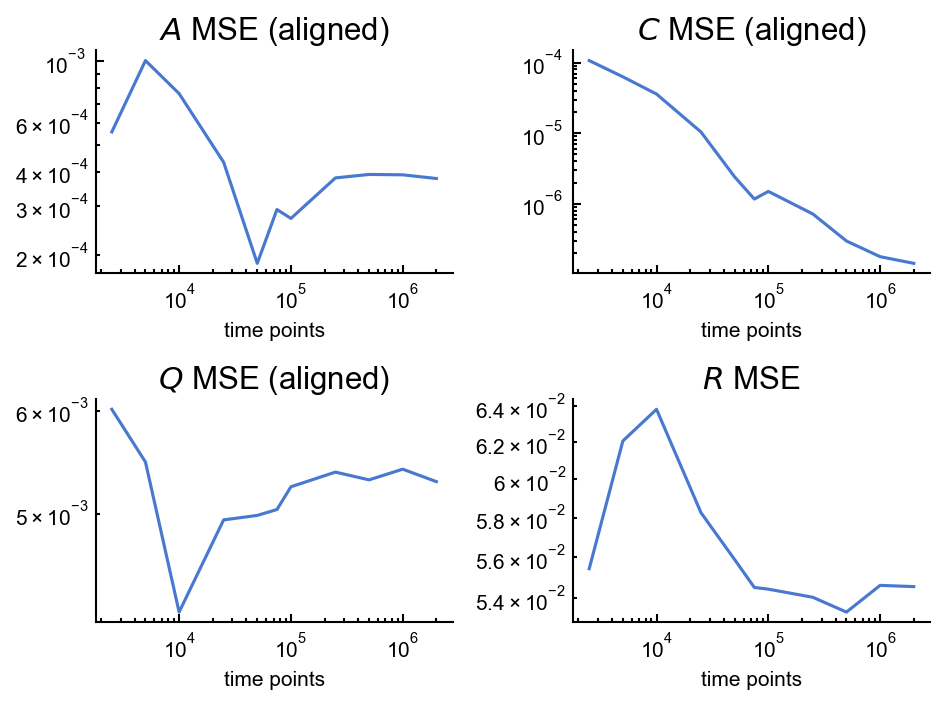

In [22]:
fig, axes = plt.subplots(2, 2)
titles = ['$A$ MSE (aligned)', '$C$ MSE (aligned)', '$Q$ MSE (aligned)', '$R$ MSE']
losses = [A_loss, C_loss, Q_loss, R_loss]

for ax, title, loss in zip(axes.flat, titles, losses):
    ax.plot(50 * np.array(trial_list), loss)
    ax.set_title(title)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('time points')

fig.tight_layout()